# Traditional DSP-Based HR Estimation from synchronous PPG and ACC data

In this notebook, a classical approach is taken to estimate HR from the DaLiA PPG dataset.

Preprocessing:
- Decimation to 32 Hz samplerate
- BPF
- Break in to 8s windows with 2s stride
- Per window z-score norm

In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
import os
from scipy.signal import butter, sosfiltfilt, decimate

%matplotlib widget

plt.close('all')

In [2]:
# Preprocessing constants

DATA_ROOT = "/Volumes/LPM02 storage/Datasets/Bio/DaLiA/data"
FS = 32
FS_PPG_RAW = 64  # Hz — original PPG sample rate before decimation
FS_ACC_RAW = 32  # Hz — original ACC sample rate (no change)
BPF_ORDER = 4
BPF_FC1 = 0.4
BPF_FC2 = 4.0
T_WIN = 8.0
T_STRIDE = 2.0
N_WIN = int(T_WIN * FS)       # samples per window: 256
N_STRIDE = int(T_STRIDE * FS) # samples per stride: 64
N_SUBJECTS = 15

In [3]:
# Load raw data for all subjects

data_raw = {}

for s in range(1, N_SUBJECTS + 1):
    subj_id = f"S{s}"
    path = os.path.join(DATA_ROOT, subj_id, f"{subj_id}.pkl")
    with open(path, 'rb') as f:
        d = pkl.load(f, encoding='latin1')
    data_raw[subj_id] = {
        'ppg': d['signal']['wrist']['BVP'],
        'acc': d['signal']['wrist']['ACC'],
        'label': d['label'],
    }
    print(f"{subj_id} loaded — PPG: {data_raw[subj_id]['ppg'].shape}, "
          f"ACC: {data_raw[subj_id]['acc'].shape}, "
          f"labels: {data_raw[subj_id]['label'].shape}")

S1 loaded — PPG: (589568, 1), ACC: (294784, 3), labels: (4603,)
S2 loaded — PPG: (525120, 1), ACC: (262560, 3), labels: (4099,)
S3 loaded — PPG: (559424, 1), ACC: (279712, 3), labels: (4367,)
S4 loaded — PPG: (585600, 1), ACC: (292800, 3), labels: (4572,)
S5 loaded — PPG: (595520, 1), ACC: (297760, 3), labels: (4649,)
S6 loaded — PPG: (336000, 1), ACC: (168000, 3), labels: (2622,)
S7 loaded — PPG: (597952, 1), ACC: (298976, 3), labels: (4668,)
S8 loaded — PPG: (517120, 1), ACC: (258560, 3), labels: (4037,)
S9 loaded — PPG: (547840, 1), ACC: (273920, 3), labels: (4277,)
S10 loaded — PPG: (681472, 1), ACC: (340736, 3), labels: (5321,)
S11 loaded — PPG: (579072, 1), ACC: (289536, 3), labels: (4521,)
S12 loaded — PPG: (506496, 1), ACC: (253248, 3), labels: (3954,)
S13 loaded — PPG: (584704, 1), ACC: (292352, 3), labels: (4565,)
S14 loaded — PPG: (573312, 1), ACC: (286656, 3), labels: (4476,)
S15 loaded — PPG: (508096, 1), ACC: (254048, 3), labels: (3966,)


In [4]:
# Preprocess (and window) all subjects

from scipy.signal import resample_poly
from math import gcd

def get_resample_factors(fs_original, fs_target):
    """Compute up/down factors for resample_poly given original and target sample rates."""
    g = gcd(fs_original, fs_target)
    return fs_target // g, fs_original // g

sos = butter(BPF_ORDER, [BPF_FC1, BPF_FC2], btype='bandpass', fs=FS, output='sos')

up_ppg, down_ppg = get_resample_factors(FS_PPG_RAW, FS)
up_acc, down_acc = get_resample_factors(FS_ACC_RAW, FS)

print(f"PPG resample factors: up={up_ppg}, down={down_ppg} ({FS_PPG_RAW} -> {FS} Hz)")
print(f"ACC resample factors: up={up_acc}, down={down_acc} ({FS_ACC_RAW} -> {FS} Hz)")

data_preproc = {}

for subj_id, d in data_raw.items():
    # Resample to target FS
    ppg = resample_poly(d['ppg'], up_ppg, down_ppg, axis=0)
    if (up_acc, down_acc) != (1, 1):
        acc = resample_poly(d['acc'], up_acc, down_acc, axis=0)
    else:
        acc = d['acc'].copy()

    # BPF — identical filter applied to both at target FS
    ppg = sosfiltfilt(sos, ppg, axis=0)
    acc = sosfiltfilt(sos, acc, axis=0)

    # Window and normalize
    n_samples = len(ppg)
    n_windows = (n_samples - N_WIN) // N_STRIDE + 1

    ppg_wins = np.zeros((n_windows, N_WIN, 1))
    acc_wins = np.zeros((n_windows, N_WIN, 3))

    for i in range(n_windows):
        start = i * N_STRIDE
        end   = start + N_WIN

        p = ppg[start:end]
        ppg_wins[i] = (p - np.mean(p)) / np.std(p)

        a = acc[start:end]
        acc_wins[i] = (a - np.mean(a, axis=0)) / np.std(a, axis=0)

    data_preproc[subj_id] = {
        'ppg':   ppg_wins,
        'acc':   acc_wins,
        'label': d['label'][:n_windows],
    }
    print(f"{subj_id} — windows: {n_windows}, labels: {len(d['label'][:n_windows])}")

PPG resample factors: up=1, down=2 (64 -> 32 Hz)
ACC resample factors: up=1, down=1 (32 -> 32 Hz)
S1 — windows: 4603, labels: 4603
S2 — windows: 4099, labels: 4099
S3 — windows: 4367, labels: 4367
S4 — windows: 4572, labels: 4572
S5 — windows: 4649, labels: 4649
S6 — windows: 2622, labels: 2622
S7 — windows: 4668, labels: 4668
S8 — windows: 4037, labels: 4037
S9 — windows: 4277, labels: 4277
S10 — windows: 5321, labels: 5321
S11 — windows: 4521, labels: 4521
S12 — windows: 3954, labels: 3954
S13 — windows: 4565, labels: 4565
S14 — windows: 4476, labels: 4476
S15 — windows: 3966, labels: 3966


In [5]:
def nlms_filter(ppg, acc, mu, filter_len, eps=1e-8):
    """
    NLMS adaptive filter for motion artifact removal from PPG using ACC as reference.

    For each ACC channel, an NLMS adaptive filter estimates the motion artifact
    component v(n) in the observed PPG d(n) = s(n) + v(n). The error signal
    e(n) = d(n) - y(n) converges to the clean cardiac signal s(n) as the
    filter output y(n) converges to v(n).

    Inputs:
        ppg:        (N, 1)   normalized PPG window (desired signal d(n))
        acc:        (N, channels)   normalized ACC window (reference signal x(n))
        mu:         float    NLMS step size (0 < mu < 2)
        filter_len: int      number of adaptive filter taps
        eps:        float    stability constant to prevent division by zero

    Returns:
        ppg_clean:  (N, channels)   cleaned PPG signal, one per ACC channel
    """

    assert ppg.ndim == 2 and ppg.shape[1] == 1, "ppg must be shape (N, 1)"
    assert acc.ndim == 2, "acc must be shape (N, channels)"
    assert ppg.shape[0] == acc.shape[0], "ppg and acc must have equal length along dim 0"
    assert 0 < mu < 2, "mu must be in (0, 2) for NLMS stability"

    N = ppg.shape[0]
    channels = acc.shape[1]

    ppg_clean = np.zeros((N, channels))

    for c in range(channels):
        w = np.zeros(filter_len)

        for i in range(filter_len, N):
            x = np.flip(acc[i - filter_len + 1:i + 1, c])
            y = np.dot(w, x)
            e = ppg[i, 0] - y
            norm = np.dot(x, x) + eps
            w += (mu / norm) * e * x
            ppg_clean[i, c] = e

    return ppg_clean

3.0 Hz power before NLMS: 3964.7475
3.0 Hz power after NLMS:  1.4679
Suppression:            -34.3 dB


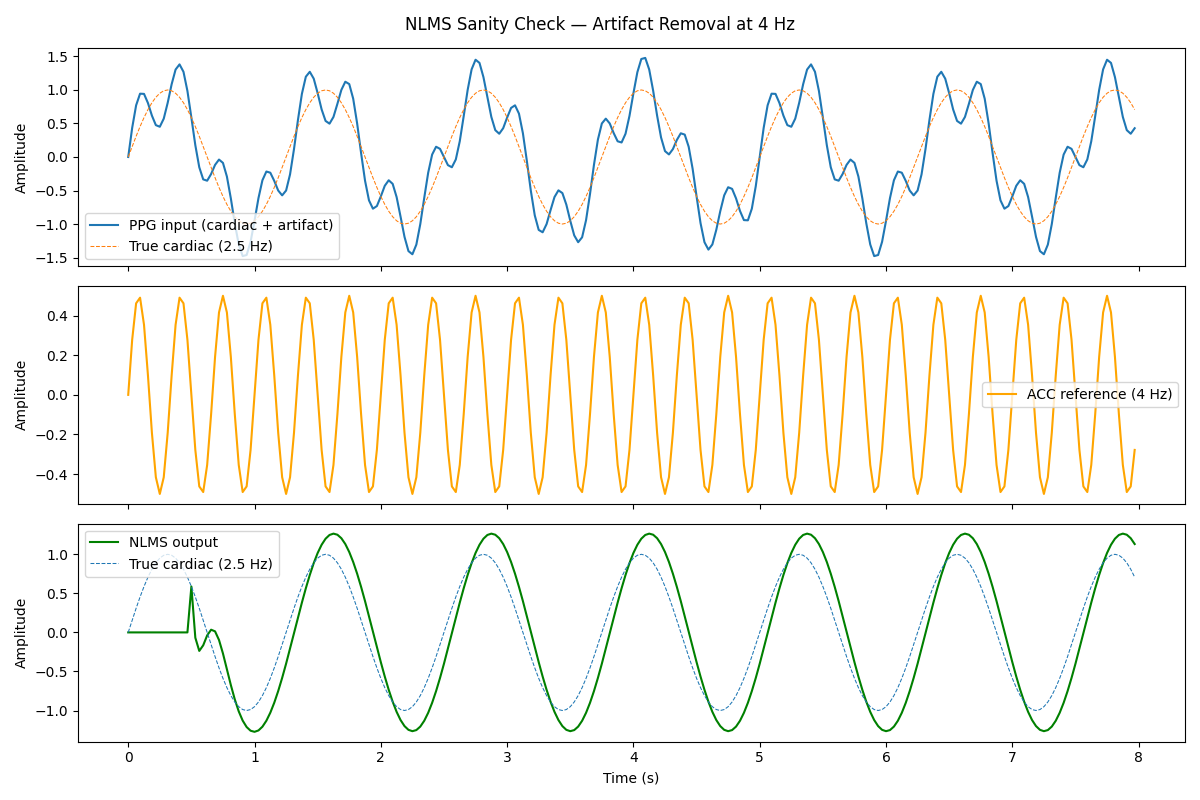

In [6]:
# NLMS sanity check
#
# PPG = ___ Hz sine (cardiac) + ___ Hz sine at -6 dB (artifact)
# ACC = ___ Hz sine (motion reference)
# Expect: substantial removal of ___ Hz component from PPG after NLMS

FS_TEST = 32
T_TEST = 8.0
N_TEST = int(FS_TEST * T_TEST)
t_test = np.arange(N_TEST) / FS_TEST

# Construct signals
f_cardio = 0.8
f_artifact = 3.0
cardiac  = np.sin(2 * np.pi * f_cardio * t_test)
artifact = 0.5 * np.sin(2 * np.pi * f_artifact * t_test)  # -6 dB ~ amplitude 0.5

ppg_test = (cardiac + artifact).reshape(-1, 1)
acc_test = artifact.reshape(-1, 1)  # single channel reference

# Run NLMS
MU_TEST         = 0.5
FILTER_LEN_TEST = 16
ppg_clean_test  = nlms_filter(ppg_test, acc_test, mu=MU_TEST, filter_len=FILTER_LEN_TEST)

# Quantify suppression via FFT
def power_at_freq(signal, target_freq, fs):
    N = len(signal)
    freqs = np.fft.rfftfreq(N, d=1/fs)
    spectrum = np.abs(np.fft.rfft(signal)) ** 2
    idx = np.argmin(np.abs(freqs - target_freq))
    return spectrum[idx]

p_before = power_at_freq(ppg_test[:, 0],       f_artifact, FS_TEST)
p_after  = power_at_freq(ppg_clean_test[:, 0], f_artifact, FS_TEST)
suppression_db = 10 * np.log10(p_after / p_before)
print(f"{f_artifact} Hz power before NLMS: {p_before:.4f}")
print(f"{f_artifact} Hz power after NLMS:  {p_after:.4f}")
print(f"Suppression:            {suppression_db:.1f} dB")

# Plot
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
ax[0].plot(t_test, ppg_test[:, 0], label='PPG input (cardiac + artifact)')
ax[0].plot(t_test, cardiac, '--', label='True cardiac (2.5 Hz)', lw=0.75)
ax[0].set_ylabel('Amplitude')
ax[0].legend()
ax[1].plot(t_test, acc_test[:, 0], label='ACC reference (4 Hz)', color='orange')
ax[1].set_ylabel('Amplitude')
ax[1].legend()
ax[2].plot(t_test, ppg_clean_test[:, 0], label='NLMS output', color='green')
ax[2].plot(t_test, cardiac, '--', label='True cardiac (2.5 Hz)', lw=0.75)
ax[2].set_ylabel('Amplitude')
ax[2].set_xlabel('Time (s)')
ax[2].legend()
plt.suptitle('NLMS Sanity Check — Artifact Removal at 4 Hz')
plt.tight_layout()
plt.show()

/var/folders/bq/csqgvczj6jndm459wzs6n4kw0000gn/T/ipykernel_33474/1306997282.py:23: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, 1, figsize=(12, 8))


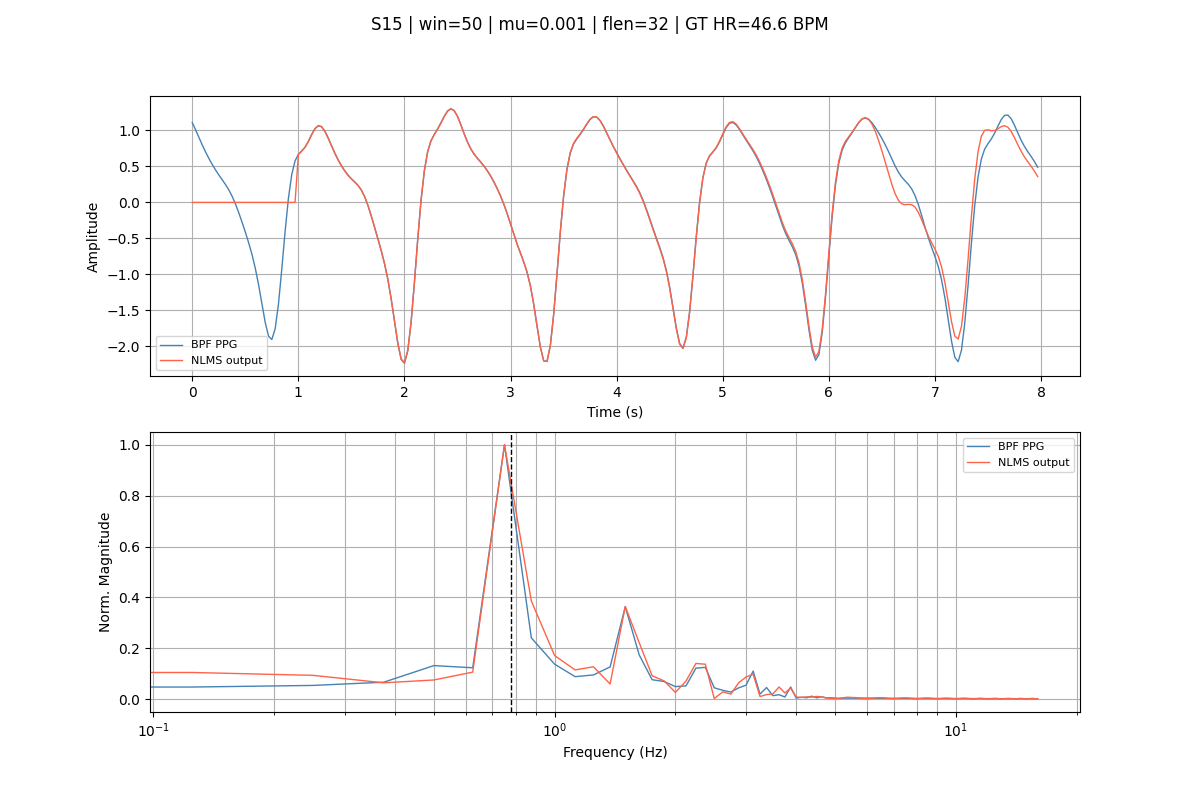

In [38]:
# Plot NLMS for one subject, one window

SUBJ_TEST    = 'S15'
WIN_TEST     = 50
MU_TEST      = 0.001
FILT_LEN_TEST = 32

ppg_win  = data_preproc[SUBJ_TEST]['ppg'][WIN_TEST]
acc_win  = data_preproc[SUBJ_TEST]['acc'][WIN_TEST]
hr_gt    = data_preproc[SUBJ_TEST]['label'][WIN_TEST]

ppg_clean = nlms_filter(ppg_win, acc_win, mu=MU_TEST, filter_len=FILT_LEN_TEST)
ppg_comb  = np.mean(ppg_clean, axis=1)

t_win = np.arange(N_WIN) / FS
f_hz  = rfftfreq(N_WIN, d=1/FS)
X_in  = np.abs(rfft(ppg_win[:, 0]))
X_out = np.abs(rfft(ppg_comb))
X_in  /= np.max(X_in)
X_out /= np.max(X_out)

plt.close()
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(t_win, ppg_win[:, 0], lw=1.0, color='steelblue', label='BPF PPG')
axes[0].plot(t_win, ppg_comb,      lw=1.0, color='tomato',    label='NLMS output')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].legend(fontsize=8)
axes[0].grid(True)

axes[1].semilogx(f_hz, X_in,  lw=1.0, color='steelblue', label='BPF PPG')
axes[1].semilogx(f_hz, X_out, lw=1.0, color='tomato',    label='NLMS output')
axes[1].axvline(bpm2hz(hr_gt), color='k', linestyle='--', lw=1.0)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Norm. Magnitude')
axes[1].legend(fontsize=8)
axes[1].grid(True, which='both')

plt.suptitle(f'{SUBJ_TEST} | win={WIN_TEST} | mu={MU_TEST} | flen={FILT_LEN_TEST} | GT HR={hr_gt:.1f} BPM')
plt.show()

## NLMS limitations

- Over a range of subjects, window indices (activities), filter lengths, and mu parameters, it seems that NLMS adaptive filtering provides no noise suppression benefits, and in some cases can degrade the actual PPG data

In [7]:
# Freq domain HR estimation

from scipy.fft import rfft, rfftfreq

# Helper function to convert hz to bpm
def hz2bpm(freq_hz):
    return freq_hz * 60

# Helper function to convert bpm to hz
def bpm2hz(bpm):
    return bpm / 60
    
# Freq domain estimator
def hr_est_freq(ppg_clean, hr_prev, hr_min, hr_max, hr_delta, fs=FS, combine='multiply'):
    """
    Frequency-domain HR estimation from NLMS-cleaned PPG.

    Computes FFT magnitude across ACC channels, combines across channels,
    masks to physiological HR range, and selects the dominant spectral peak.
    If hr_prev is provided, constrains peak search to within +/- hr_delta BPM
    of the previous estimate. Falls back to global physiological range peak
    if no peak exists within the delta constraint.

    Inputs:
        ppg_clean:  (N, channels)  NLMS-cleaned PPG, one column per ACC channel
        hr_prev:    float or None  previous HR estimate in BPM, or None for first window
        hr_min:     float          minimum physiological HR in BPM
        hr_max:     float          maximum physiological HR in BPM
        hr_delta:   float          maximum allowable HR change per window in BPM
        fs:         int            sample rate in Hz
        combine:    str            'multiply' or 'avg' — method to combine channels

    Returns:
        hr_est:     float          estimated HR in BPM
    """

    assert ppg_clean.ndim == 2 and ppg_clean.shape[1] >= 1, "ppg_clean must be (N, channels)"
    assert hr_min < hr_max, "hr_min must be less than hr_max"
    assert hr_delta > 0, "hr_delta must be positive"
    assert fs > 0, "fs must be positive"
    assert combine in ('multiply', 'avg'), "combine must be 'multiply' or 'avg'"

    N = ppg_clean.shape[0]

    # FFT magnitude, positive frequencies only
    X = np.abs(rfft(ppg_clean, axis=0))           # (N//2+1, channels)
    f_hz  = rfftfreq(N, d=1/fs)                   # (N//2+1,)
    f_bpm = hz2bpm(f_hz)                          # (N//2+1,)

    # Normalize each channel to [0, 1]
    X /= np.max(X, axis=0)

    # Combine channels
    if ppg_clean.shape[1] > 1:
        if combine == 'multiply':
            X = np.prod(X, axis=1)
        else:
            X = np.mean(X, axis=1)
    else:
        X = X.squeeze()

    # Apply physiological range mask
    mask = (f_bpm >= hr_min) & (f_bpm <= hr_max)
    X_masked = X * mask

    # Apply delta constraint if hr_prev provided
    if hr_prev is not None:
        mask_delta = (f_bpm >= hr_prev - hr_delta) & (f_bpm <= hr_prev + hr_delta)
        X_delta = X_masked * mask_delta

        if np.any(X_delta > 0):
            return f_bpm[np.argmax(X_delta)]
        else:
            return hr_prev
    else:
        return f_bpm[np.argmax(X_masked)]

In [8]:
# # Time domain HR estimation

# def hr_est_time(ppg_clean, hr_prev, hr_min, hr_max, hr_delta, fs=FS):
#     """
#     """

#     assert ppg_clean.ndim == 2 and ppg_clean.shape[1] >= 1, "ppg_clean must be (N, channels)"
#     assert hr_min < hr_max, "hr_min must be less than hr_max"
#     assert hr_delta > 0, "hr_delta must be positive"
#     assert fs > 0, "fs must be positive"

#     # Average ppg_clean
#     X = np.mean(ppg_clean, axis=1)
#     X = X.squeeze()

#     # Rectify (pwr)
#     X *= X

#     # 

## HR Estimation methods